Saved: metrics_plot.png
Saved: convergence_elbow.png


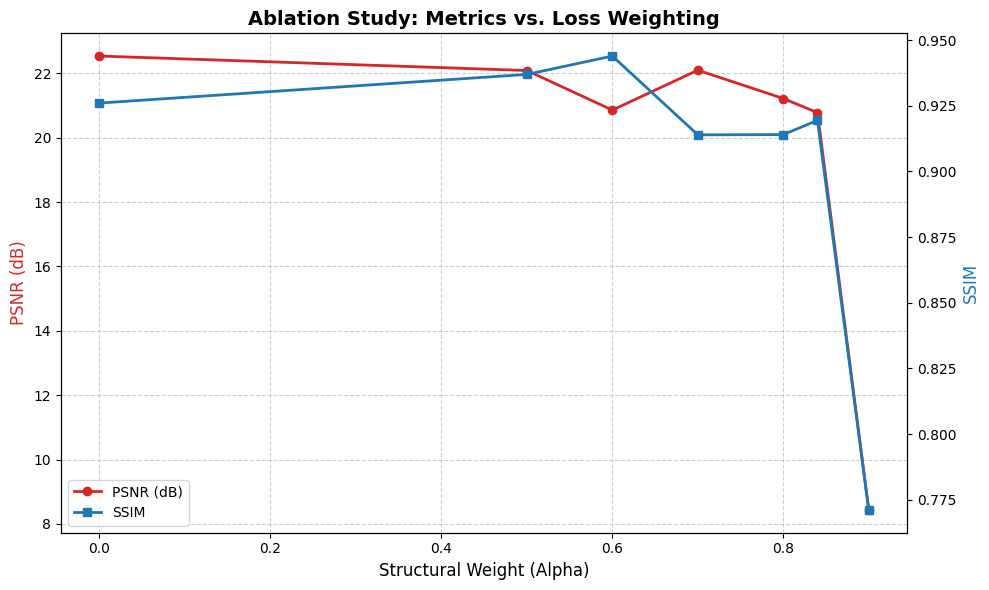

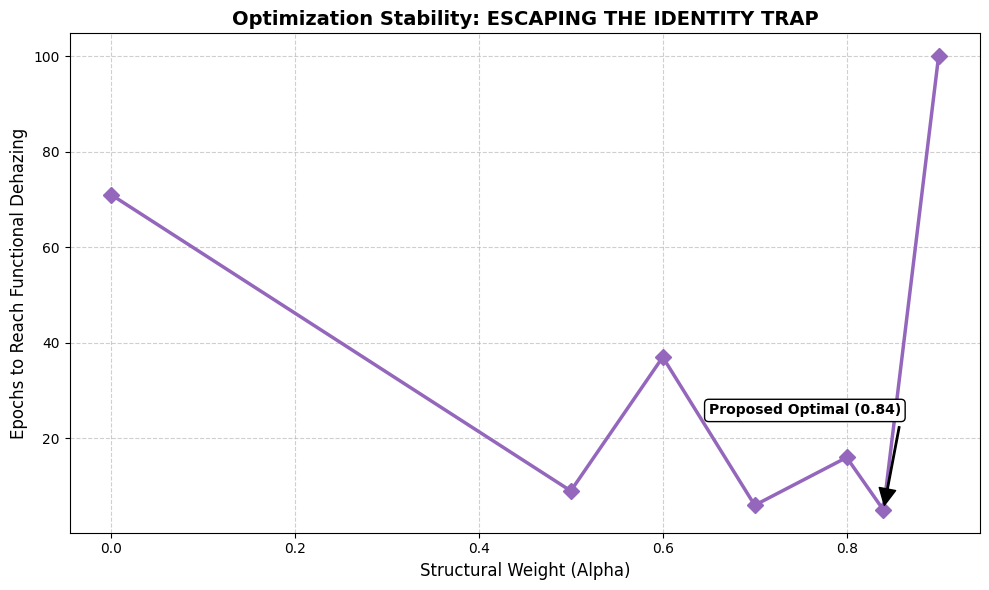

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your results from the CSV
df = pd.read_csv('ablation_results.csv')

# 2. Add the 'Breakthrough Epoch' data we observed from your logs
# This is the epoch where the model escaped the "Identity Trap" (PSNR > 15)
breakthrough_data = {
    0.00: 71,
    0.50: 9,
    0.60: 37,
    0.70: 6,
    0.80: 16,
    0.84: 5,
    0.90: 100 # Failed to break through
}
df['breakthrough'] = df['alpha'].map(breakthrough_data)

# Sort by alpha to ensure lines connect correctly
df = df.sort_values(by='alpha')

# --- FIGURE 1: METRIC SENSITIVITY ---
# Shows how PSNR and SSIM trade off as Alpha increases
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot PSNR on left axis
line1 = ax1.plot(df['alpha'], df['psnr'], 'o-', color='#d62728', label='PSNR (dB)', linewidth=2)
# Plot SSIM on right axis
line2 = ax2.plot(df['alpha'], df['ssim'], 's-', color='#1f77b4', label='SSIM', linewidth=2)

ax1.set_xlabel('Structural Weight (Alpha)', fontsize=12)
ax1.set_ylabel('PSNR (dB)', color='#d62728', fontsize=12)
ax2.set_ylabel('SSIM', color='#1f77b4', fontsize=12)
plt.title('Ablation Study: Metrics vs. Loss Weighting', fontsize=14, fontweight='bold')

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('metrics_plot.png', dpi=300)
print("Saved: metrics_plot.png")

# --- FIGURE 2: THE CONVERGENCE ELBOW ---
# Proves that 0.84 is the "sweet spot" for training stability
plt.figure(figsize=(10, 6))
plt.plot(df['alpha'], df['breakthrough'], 'D-', color='#9467bd', linewidth=2.5, markersize=8)

# Annotate the Proposed optimal point
plt.annotate('Proposed Optimal (0.84)', xy=(0.84, 5), xytext=(0.65, 25),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="w"))

plt.xlabel('Structural Weight (Alpha)', fontsize=12)
plt.ylabel('Epochs to Reach Functional Dehazing', fontsize=12)
plt.title('Optimization Stability: ESCAPING THE IDENTITY TRAP', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('convergence_elbow.png', dpi=300)
print("Saved: convergence_elbow.png")